In [1]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
exp_root = "/media/yesindeed/DATADRIVE1/mount/remote_cse/experiments/med_vlm_benchmark/diagnosis"

df_results = pd.read_csv(os.path.join(exp_root, "exp_status.csv"))

df_results

,dataset,model,strategy,pred_file,rel_path,n,auroc,ci_low,ci_high,auc_std,status
0,Camelyon17,BLIP2-2.7b,eval_seed0/original_pretrained,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/eval_seed0/original_pret...,920,0.517358,0.479656,0.555933,0.019424,OK
1,Camelyon17,BLIP2-2.7b,train_img-lora-lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_img-lora-lp_seed42,920,0.982491,0.975661,0.988340,0.003237,OK
2,Camelyon17,BLIP2-2.7b,train_lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_lp_seed42,920,0.981262,0.974411,0.987425,0.003409,OK
3,Camelyon17,BioMedCLIP,eval_seed0/original_pretrained,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/eval_seed0/original_pret...,920,0.771692,0.741732,0.802931,0.015638,OK
4,Camelyon17,BioMedCLIP,train_img-lora-lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/train_img-lora-lp_seed42,920,0.986990,0.981275,0.992037,0.002773,OK
...,...,...,...,...,...,...,...,...,...,...,...
139,PAPILA,PubMedCLIP,train_img-lora-lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_img-lora-lp_seed42,56,0.794326,0.658853,0.915159,0.066019,OK
140,PAPILA,PubMedCLIP,train_lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_lp_seed42,56,0.517730,0.307061,0.734405,0.107715,OK
141,PAPILA,SigLIP,eval_seed0/original_pretrained,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/eval_seed0/original_pretrained,56,0.517730,0.327592,0.734383,0.104283,OK
142,PAPILA,SigLIP,train_img-lora-lp_seed42,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/train_img-lora-lp_seed42,56,0.713948,0.533528,0.876771,0.086208,OK


In [3]:
df_results["strategy"].value_counts()

strategy
eval_seed0/original_pretrained    48
train_img-lora-lp_seed42          48
train_lp_seed42                   48
Name: count, dtype: int64

In [4]:
df_results["strategy"] = df_results["strategy"].replace(
    "train_img-lora-lp_seed42", "FT-LoRA")
df_results["strategy"] = df_results["strategy"].replace(
    "train_lp_seed42", "FT-LP")
df_results["strategy"] = df_results["strategy"].replace(
    "eval_seed0/original_pretrained", "ZS")


df_results["strategy"].value_counts()

strategy
ZS         48
FT-LoRA    48
FT-LP      48
Name: count, dtype: int64

In [6]:
import json
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

auroc = []
ci_low = []
ci_high = []

for i in tqdm(range(len(df_results))):
    row = df_results.iloc[i]

    with open(os.path.join(exp_root, row["rel_path"], "bootstrap_meta.json")) as fp:
        data = json.load(fp)

    auc_list = []
    for boots in data.values():
        prob = boots["prob"]
        label = boots["label"]

        auc_list.append(roc_auc_score(label, prob))

    auc_array = np.array(auc_list)

    mean_auc = np.mean(auc_array)
    lower = np.percentile(auc_array, 2.5)
    upper = np.percentile(auc_array, 97.5)

    auroc.append(mean_auc)
    ci_low.append(lower)
    ci_high.append(upper)

df_results["auroc"] = auroc
df_results["ci_low"] = ci_low
df_results["ci_high"] = ci_high

df_results

100%|██████████| 144/144 [04:33<00:00,  1.90s/it]


,dataset,model,strategy,pred_file,rel_path,n,auroc,ci_low,ci_high,auc_std,status,is_ood,model_family,model_type
0,Camelyon17,BLIP2-2.7b,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/eval_seed0/original_pret...,920,0.517506,0.479656,0.555933,0.019424,OK,1,CLIP,general
1,Camelyon17,BLIP2-2.7b,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_img-lora-lp_seed42,920,0.982731,0.975661,0.988340,0.003237,OK,1,CLIP,general
2,Camelyon17,BLIP2-2.7b,FT-LP,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_lp_seed42,920,0.981502,0.974411,0.987425,0.003409,OK,1,CLIP,general
3,Camelyon17,BioMedCLIP,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/eval_seed0/original_pret...,920,0.772451,0.741732,0.802931,0.015638,OK,0,CLIP,medical
4,Camelyon17,BioMedCLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/train_img-lora-lp_seed42,920,0.987067,0.981275,0.992037,0.002773,OK,0,CLIP,medical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,PAPILA,PubMedCLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_img-lora-lp_seed42,56,0.791376,0.650911,0.910884,0.066019,OK,1,CLIP,medical
140,PAPILA,PubMedCLIP,FT-LP,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_lp_seed42,56,0.514518,0.316622,0.729200,0.107715,OK,1,CLIP,medical
141,PAPILA,SigLIP,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/eval_seed0/original_pretrained,56,0.520777,0.313030,0.730567,0.104283,OK,1,SigLIP,general
142,PAPILA,SigLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/train_img-lora-lp_seed42,56,0.715907,0.548388,0.877552,0.086208,OK,1,SigLIP,general


In [10]:
ID_dict = {
    "MedCLIP": ["CheXpert"],
    "PubMedCLIP": ["CheXpert"],
    "BioMedCLIP": ["CheXpert", "HAM10000", "Camelyon17"],
    "PLIP": ["Camelyon17"],
    "MedSigLIP": ["CheXpert", "Camelyon17", "PAPILA", "HAM10000", "PAPILA"],
}

general_models = ["CLIP", "BLIP2-2.7b", "SigLIP"]

model_familis = []
model_types = []
is_ood = []

for dataset, model in zip(df_results["dataset"].tolist(), df_results["model"].tolist()):
    if not model in ID_dict.keys():
        is_ood.append(1)
    elif dataset not in ID_dict[model]:
        is_ood.append(1)
    else:
        is_ood.append(0)

    if model in general_models:
        model_types.append("general")
    else:
        model_types.append("medical")

    if "SigLIP" in model:
        model_familis.append("SigLIP")
    else:
        model_familis.append("CLIP")


df_results["is_ood"] = is_ood
df_results["model_family"] = model_familis
df_results["model_type"] = model_types

df_results

,dataset,model,strategy,pred_file,rel_path,n,auroc,ci_low,ci_high,auc_std,status,is_ood,model_family,model_type
0,Camelyon17,BLIP2-2.7b,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/eval_seed0/original_pret...,920,0.517506,0.479656,0.555933,0.019424,OK,1,CLIP,general
1,Camelyon17,BLIP2-2.7b,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_img-lora-lp_seed42,920,0.982731,0.975661,0.988340,0.003237,OK,1,CLIP,general
2,Camelyon17,BLIP2-2.7b,FT-LP,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BLIP2-2.7b/train_lp_seed42,920,0.981502,0.974411,0.987425,0.003409,OK,1,CLIP,general
3,Camelyon17,BioMedCLIP,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/eval_seed0/original_pret...,920,0.772451,0.741732,0.802931,0.015638,OK,0,CLIP,medical
4,Camelyon17,BioMedCLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,Camelyon17/BioMedCLIP/train_img-lora-lp_seed42,920,0.987067,0.981275,0.992037,0.002773,OK,0,CLIP,medical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,PAPILA,PubMedCLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_img-lora-lp_seed42,56,0.791376,0.650911,0.910884,0.066019,OK,1,CLIP,medical
140,PAPILA,PubMedCLIP,FT-LP,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/PubMedCLIP/train_lp_seed42,56,0.514518,0.316622,0.729200,0.107715,OK,1,CLIP,medical
141,PAPILA,SigLIP,ZS,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/eval_seed0/original_pretrained,56,0.520777,0.313030,0.730567,0.104283,OK,1,SigLIP,general
142,PAPILA,SigLIP,FT-LoRA,/project/6101776/nanboy/MedVLMBench/log/diagno...,PAPILA/SigLIP/train_img-lora-lp_seed42,56,0.715907,0.548388,0.877552,0.086208,OK,1,SigLIP,general


In [11]:
df_results.to_csv("results/boot_results_diagnosis.csv", index=False)

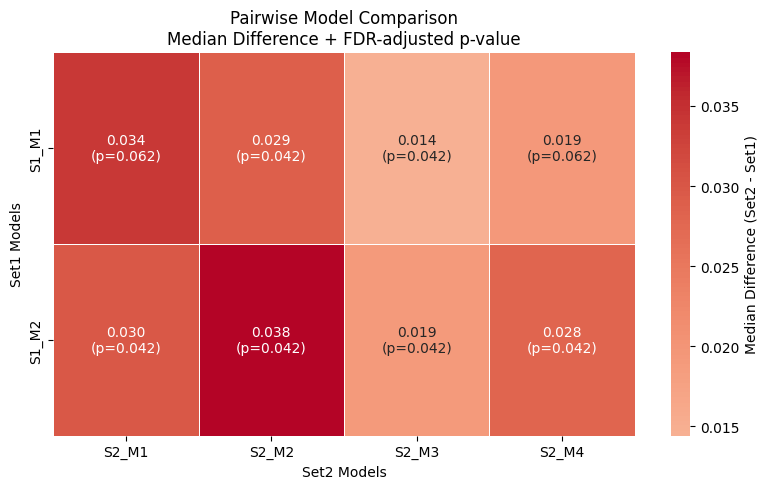

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

np.random.seed(42)

# -------------------------------------------------
# 1️⃣ 模拟数据
# -------------------------------------------------

datasets = [f"D{i}" for i in range(1, 7)]
set1_models = ["S1_M1", "S1_M2"]
set2_models = ["S2_M1", "S2_M2", "S2_M3", "S2_M4"]

rows = []

for d in datasets:
    dataset_effect = np.random.normal(0, 0.015)

    # Set1 baseline
    for m in set1_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.78 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set1", m, acc])

    # Set2 slightly better
    for m in set2_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.81 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set2", m, acc])

df = pd.DataFrame(rows, columns=["Dataset", "Set", "Model", "Accuracy"])


# -------------------------------------------------
# 2️⃣ 两两 Wilcoxon + median difference
# -------------------------------------------------

median_matrix = pd.DataFrame(index=set1_models, columns=set2_models, dtype=float)

p_matrix = pd.DataFrame(index=set1_models, columns=set2_models, dtype=float)

p_values = []

for m1 in set1_models:
    for m2 in set2_models:

        # 按 dataset 对齐
        d1 = df[df["Model"] == m1].sort_values("Dataset")
        d2 = df[df["Model"] == m2].sort_values("Dataset")

        diff = d2["Accuracy"].values - d1["Accuracy"].values

        # Wilcoxon signed-rank
        stat, p = wilcoxon(diff)

        median_diff = np.median(diff)

        median_matrix.loc[m1, m2] = median_diff
        p_matrix.loc[m1, m2] = p
        p_values.append(p)


# -------------------------------------------------
# 3️⃣ FDR correction
# -------------------------------------------------

p_values_flat = np.array(p_values)
reject, pvals_corrected, _, _ = multipletests(p_values_flat, alpha=0.05, method="fdr_bh")

# 重新放回矩阵
p_matrix_corrected = pd.DataFrame(
    pvals_corrected.reshape(len(set1_models), len(set2_models)), index=set1_models, columns=set2_models
)


# -------------------------------------------------
# 4️⃣ 生成标注字符串（median + p值）
# -------------------------------------------------

annot_matrix = median_matrix.copy().astype(str)

for i in set1_models:
    for j in set2_models:
        med = median_matrix.loc[i, j]
        p_adj = p_matrix_corrected.loc[i, j]

        annot_matrix.loc[i, j] = f"{med:.3f}\n(p={p_adj:.3f})"


# -------------------------------------------------
# 5️⃣ 绘制 Heatmap
# -------------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    median_matrix.astype(float),
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Median Difference (Set2 - Set1)"},
)

plt.title("Pairwise Model Comparison\nMedian Difference + FDR-adjusted p-value")
plt.ylabel("Set1 Models")
plt.xlabel("Set2 Models")
plt.tight_layout()
plt.show()

In [8]:
df

,Dataset,Set,Model,Accuracy
0,D1,Set1,S1_M1,0.792545
1,D1,Set1,S1_M2,0.800339
2,D1,Set2,S2_M1,0.830901
3,D1,Set2,S2_M2,0.820430
4,D1,Set2,S2_M3,0.818242
5,D1,Set2,S2_M4,0.815213
6,D2,Set1,S1_M1,0.728429
7,D2,Set1,S1_M2,0.744315
8,D2,Set2,S2_M1,0.758098
9,D2,Set2,S2_M2,0.793700
